<a href="https://colab.research.google.com/github/ekuelkpodar/Complex-Systems-Google-Colab-Experiment/blob/main/Information_Diffusion_on_Social_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
The goal of this project is to simulate and analyze information diffusion in complex social networks using an agent-based modeling approach. We will implement various network topologies (Scale-free, Small-world, Random), define diverse agent types (Individuals, Influencers, Bots, Institutions), and develop a simulation engine to model social contagion, viral content, and echo chambers. Finally, we will visualize the results and analyze how network structure and agent composition influence the dynamics of information spread.

## Mathematical Framework and Network Initialization

### Subtask:
Initialize the network topologies (Scale-free, Small-world, Random) and define the parameters for the information diffusion model.


**Reasoning**:
Starting the subtask by importing the required libraries and initializing the three network types using NetworkX.



In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

# Network Parameters
NUM_NODES = 500
AVG_DEGREE = 4

# 1. Scale-free (Barabasi-Albert)
# m: number of edges to attach from a new node to existing nodes
ba_net = nx.barabasi_albert_graph(n=NUM_NODES, m=AVG_DEGREE // 2)

# 2. Small-world (Watts-Strogatz)
# k: each node is joined with its k nearest neighbors in a ring topology
# p: the probability of rewiring each edge
ws_net = nx.watts_strogatz_graph(n=NUM_NODES, k=AVG_DEGREE, p=0.1)

# 3. Random (Erdos-Renyi)
# p: probability for edge creation
er_net = nx.erdos_renyi_graph(n=NUM_NODES, p=AVG_DEGREE/(NUM_NODES-1))

print(f'Networks initialized with {NUM_NODES} nodes.')
print(f'BA edges: {ba_net.number_of_edges()}, WS edges: {ws_net.number_of_edges()}, ER edges: {er_net.number_of_edges()}')

Networks initialized with 500 nodes.
BA edges: 996, WS edges: 1000, ER edges: 989


**Reasoning**:
Define the agent attributes (susceptibility, threshold, opinion) and initialize the state of nodes in each network to prepare for the diffusion simulation.



In [2]:
import random

def initialize_node_attributes(G):
    """Initialize node attributes for the diffusion model."""
    for node in G.nodes():
        # Susceptibility to information (0 to 1)
        G.nodes[node]['susceptibility'] = np.random.uniform(0.1, 0.8)
        # Adoption threshold: fraction of neighbors required to adopt (0 to 1)
        G.nodes[node]['threshold'] = np.random.uniform(0.1, 0.5)
        # Initial state: 0 = unaware, 1 = aware/infected
        G.nodes[node]['state'] = 0
        # Agent type (default to Individual)
        G.nodes[node]['type'] = 'Individual'

# Initialize all networks
for net in [ba_net, ws_net, er_net]:
    initialize_node_attributes(net)

# Seed initial information in 1% of nodes
SEED_SIZE = max(1, int(NUM_NODES * 0.01))
for net in [ba_net, ws_net, er_net]:
    seeds = random.sample(list(net.nodes()), SEED_SIZE)
    for s in seeds:
        net.nodes[s]['state'] = 1

print(f'Node attributes initialized. Seeded {SEED_SIZE} nodes in each network.')

Node attributes initialized. Seeded 5 nodes in each network.


## Agent and Behavior Implementation

### Subtask:
Implement specific agent types (Influencers, Bots, Institutions) and define their unique behaviors in the diffusion model.


**Reasoning**:
I will assign agent types to a subset of nodes in each network and update their behavioral parameters (susceptibility and threshold) according to their type.



In [3]:
import random

def assign_agent_types(G):
    nodes = list(G.nodes())
    random.shuffle(nodes)

    num_nodes = len(nodes)
    num_influencers = int(num_nodes * 0.02)  # 2%
    num_bots = int(num_nodes * 0.05)         # 5%
    num_institutions = int(num_nodes * 0.01) # 1%

    # Slice nodes for assignment
    influencers = nodes[:num_influencers]
    bots = nodes[num_influencers : num_influencers + num_bots]
    institutions = nodes[num_influencers + num_bots : num_influencers + num_bots + num_institutions]

    for node in G.nodes():
        if node in influencers:
            G.nodes[node]['type'] = 'Influencer'
            G.nodes[node]['threshold'] = 0.05 # Very easy to adopt/spread
            G.nodes[node]['susceptibility'] = 0.9
        elif node in bots:
            G.nodes[node]['type'] = 'Bot'
            G.nodes[node]['threshold'] = 0.01 # Spreads content instantly
            G.nodes[node]['susceptibility'] = 1.0
        elif node in institutions:
            G.nodes[node]['type'] = 'Institution'
            G.nodes[node]['threshold'] = 0.2
            G.nodes[node]['susceptibility'] = 0.1 # Hard to influence
        else:
            G.nodes[node]['type'] = 'Individual'
            # Individual attributes already set in previous step

# Apply to all networks
for net in [ba_net, ws_net, er_net]:
    assign_agent_types(net)

# Verification print
from collections import Counter
counts = Counter([ba_net.nodes[n]['type'] for n in ba_net.nodes()])
print(f"Agent distribution in BA Network: {dict(counts)}")

Agent distribution in BA Network: {'Individual': 460, 'Bot': 25, 'Institution': 5, 'Influencer': 10}


## Diffusion Engine and Social Contagion Logic

### Subtask:
Develop a simulation function that models the temporal spread of information based on node states, neighbor influence, and agent-specific thresholds.


**Reasoning**:
I will now implement the simulation engine logic. I'll create a function that iterates through time steps, applying the threshold-based contagion rules to each network, and returns the diffusion history for analysis.



In [4]:
def simulate_diffusion(G, steps=20, viral_factor=1.0):
    """
    Simulates information diffusion using a threshold model.
    Returns a list containing the count of infected nodes at each step.
    """
    history = []
    # Record initial state
    history.append(sum(1 for n in G.nodes() if G.nodes[n]['state'] == 1))

    for _ in range(steps):
        newly_infected = []
        for node in G.nodes():
            if G.nodes[node]['state'] == 0:
                neighbors = list(G.neighbors(node))
                if not neighbors:
                    continue

                # Calculate fraction of infected neighbors
                infected_neighbors = sum(1 for n in neighbors if G.nodes[n]['state'] == 1)
                infection_fraction = infected_neighbors / len(neighbors)

                # Effective influence: social pressure * individual susceptibility
                influence = infection_fraction * G.nodes[node]['susceptibility'] * viral_factor

                if influence >= G.nodes[node]['threshold']:
                    newly_infected.append(node)

        # Update states for next step
        for node in newly_infected:
            G.nodes[node]['state'] = 1

        history.append(sum(1 for n in G.nodes() if G.nodes[n]['state'] == 1))

        # If no new infections occurred, we can stop early
        if not newly_infected:
            history.extend([history[-1]] * (steps - len(history) + 1))
            break

    return history

# Run simulations on each network
STEPS = 30
VIRAL_FACTOR = 1.2 # Slightly boost the content virality

# We need to work on copies to preserve original seeded states if we want to re-run
ba_history = simulate_diffusion(ba_net.copy(), steps=STEPS, viral_factor=VIRAL_FACTOR)
ws_history = simulate_diffusion(ws_net.copy(), steps=STEPS, viral_factor=VIRAL_FACTOR)
er_history = simulate_diffusion(er_net.copy(), steps=STEPS, viral_factor=VIRAL_FACTOR)

print("Simulation complete.")
print(f"Final infected counts - BA: {ba_history[-1]}, WS: {ws_history[-1]}, ER: {er_history[-1]}")

Simulation complete.
Final infected counts - BA: 11, WS: 13, ER: 15


## Network Visualization and Metrics

### Subtask:
Visualize the diffusion results through temporal curves and network snapshots.


**Reasoning**:
I am plotting the diffusion history for the BA, WS, and ER networks to compare how information spreads across different topologies. Then, I will visualize the BA network structure, coloring nodes by their infection status and sizing them by their degree.



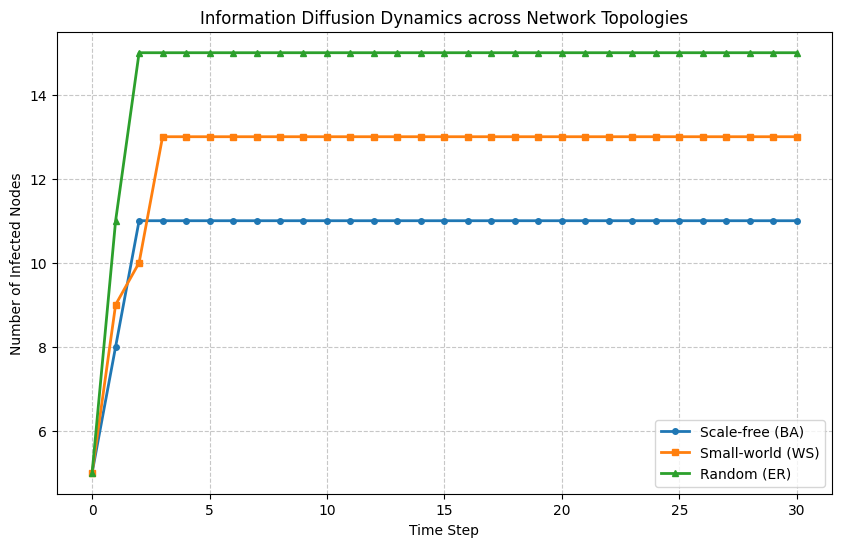

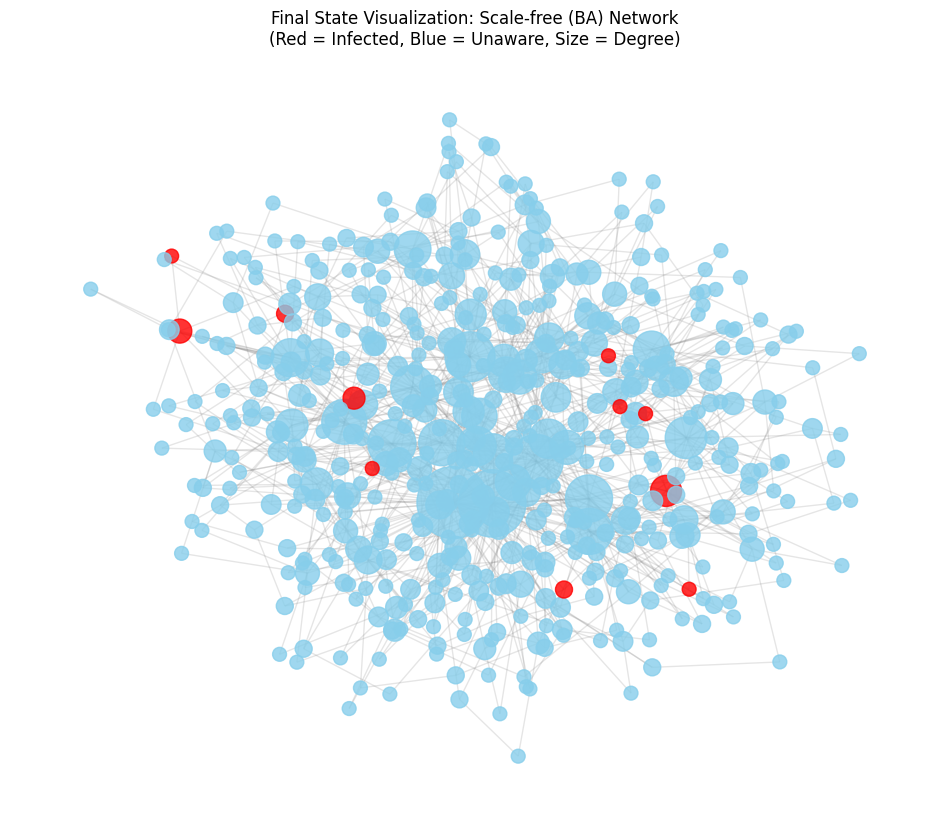

In [5]:
import matplotlib.pyplot as plt

# 1. Plot Diffusion Curves
plt.figure(figsize=(10, 6))
plt.plot(ba_history, label='Scale-free (BA)', linewidth=2, marker='o', markersize=4)
plt.plot(ws_history, label='Small-world (WS)', linewidth=2, marker='s', markersize=4)
plt.plot(er_history, label='Random (ER)', linewidth=2, marker='^', markersize=4)

plt.title('Information Diffusion Dynamics across Network Topologies')
plt.xlabel('Time Step')
plt.ylabel('Number of Infected Nodes')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 2. Visualize BA Network Final State
# Note: To show the 'final' state, we run a quick simulation on the BA net for visualization
final_ba = ba_net.copy()
# We use the results from the previously simulated logic by manually updating the copy
# Or simply re-running the simulation on this copy to get the state
_ = simulate_diffusion(final_ba, steps=STEPS, viral_factor=VIRAL_FACTOR)

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(final_ba, k=0.15, seed=42)

# Color based on state: 1 (Infected) -> Red, 0 (Unaware) -> LightBlue
node_colors = ['red' if final_ba.nodes[n]['state'] == 1 else 'skyblue' for n in final_ba.nodes()]
# Size based on degree to highlight hubs
degrees = dict(final_ba.degree())
node_sizes = [v * 50 for v in degrees.values()]

nx.draw_networkx_nodes(final_ba, pos, node_color=node_colors, node_size=node_sizes, alpha=0.8)
nx.draw_networkx_edges(final_ba, pos, alpha=0.2, edge_color='gray')

plt.title('Final State Visualization: Scale-free (BA) Network\n(Red = Infected, Blue = Unaware, Size = Degree)')
plt.axis('off')
plt.show()

## Final Task

### Subtask:
Summarize the results of the experiments and discuss how different topologies affect the potential for viral growth and polarization.
